# Fetching Gold/USD Price Data

This notebook demonstrates how to fetch historical and real-time Gold/USD price data using Yahoo Finance via the yfinance library.

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Fetch historical daily Gold/USD data (last 1 year)
gold = yf.Ticker("GC=F")
daily_data = gold.history(period="1y")

print(daily_data.tail())

                                  Open         High          Low        Close  \
Date                                                                            
2026-04-06 00:00:00-04:00  4656.100098  4689.600098  4605.000000  4656.799805   
2026-04-07 00:00:00-04:00  4624.899902  4676.299805  4608.000000  4657.100098   
2026-04-08 00:00:00-04:00  4760.000000  4851.000000  4738.799805  4749.500000   
2026-04-09 00:00:00-04:00  4711.000000  4799.100098  4711.000000  4792.200195   
2026-04-10 00:00:00-04:00  4790.500000  4810.000000  4760.399902  4773.500000   

                           Volume  Dividends  Stock Splits  
Date                                                        
2026-04-06 00:00:00-04:00     148        0.0           0.0  
2026-04-07 00:00:00-04:00     327        0.0           0.0  
2026-04-08 00:00:00-04:00     405        0.0           0.0  
2026-04-09 00:00:00-04:00     405        0.0           0.0  
2026-04-10 00:00:00-04:00   34992        0.0           0.0  


In [6]:
# Fetch historical hourly Gold/USD data (last 7 days)
hourly_data = gold.history(period="7d", interval="1h")

print(hourly_data.tail())

                                  Open         High          Low        Close  \
Datetime                                                                        
2026-04-10 00:00:00-04:00  4790.399902  4794.600098  4781.799805  4781.799805   
2026-04-10 01:00:00-04:00  4782.500000  4793.000000  4781.299805  4789.899902   
2026-04-10 02:00:00-04:00  4790.000000  4790.200195  4766.299805  4769.700195   
2026-04-10 03:00:00-04:00  4769.600098  4781.200195  4764.600098  4773.000000   
2026-04-10 04:00:00-04:00  4773.299805  4774.799805  4772.200195  4774.100098   

                           Volume  Dividends  Stock Splits  
Datetime                                                    
2026-04-10 00:00:00-04:00    2037        0.0           0.0  
2026-04-10 01:00:00-04:00    2041        0.0           0.0  
2026-04-10 02:00:00-04:00    4933        0.0           0.0  
2026-04-10 03:00:00-04:00    2815        0.0           0.0  
2026-04-10 04:00:00-04:00       0        0.0           0.0  


In [7]:
# Fetch real-time (latest) Gold/USD price
latest_data = gold.history(period="1d")
latest_price = latest_data['Close'].iloc[-1]
print(f"Latest Gold/USD price: ${latest_price:.2f}")

Latest Gold/USD price: $4774.10


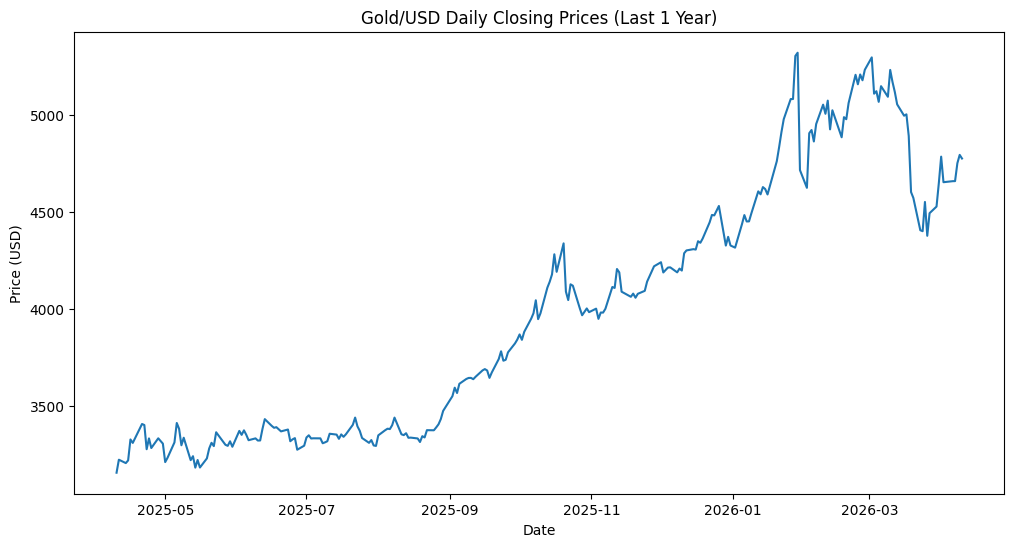

In [8]:
# Plot the daily closing prices
plt.figure(figsize=(12,6))
plt.plot(daily_data.index, daily_data['Close'])
plt.title('Gold/USD Daily Closing Prices (Last 1 Year)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

# Machine Learning Model for Gold/USD Price Prediction

We will develop an LSTM neural network to predict future Gold/USD prices based on historical data. LSTM is suitable for time series forecasting as it can capture long-term dependencies.

In [9]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression

In [10]:
# Prepare data for LSTM
data = daily_data['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days to predict next
X, y = create_sequences(scaled_data, seq_length)

# Split into train and test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [11]:
# Build LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50


c:\Ironhack\Capstone 2\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.1944 - val_loss: 0.1006
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0261 - val_loss: 0.1156
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0325 - val_loss: 0.0131
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0110 - val_loss: 0.0276
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0118 - val_loss: 0.0169
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0086 - val_loss: 0.0158
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0094 - val_loss: 0.0241
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0079 - val_loss: 0.0154
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0052 - val_loss: 0.0124
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0082 - val_loss: 0.0158
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0050 - val_loss: 0.0235
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0047 - val_loss: 0.0199
Epoch 13/50


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
LSTM RMSE: 289.6385282188464


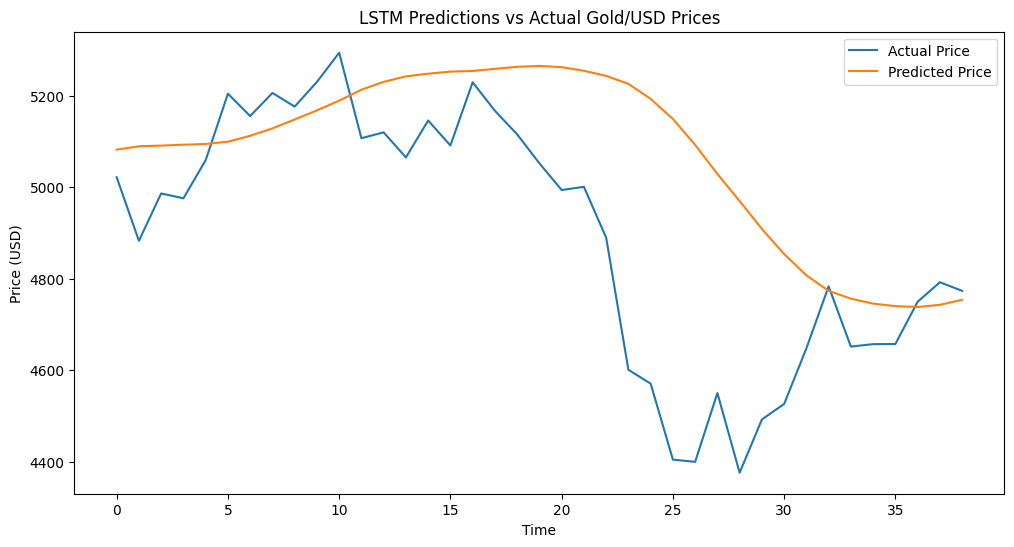

In [12]:
# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'LSTM RMSE: {rmse}')

# Plot predictions vs actual
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title('LSTM Predictions vs Actual Gold/USD Prices')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## ARIMA Model

As an alternative, we can use an ARIMA model for time series forecasting.

ARIMA RMSE: 434.3108217637347


c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Ironhack\Capstone 2\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_predic

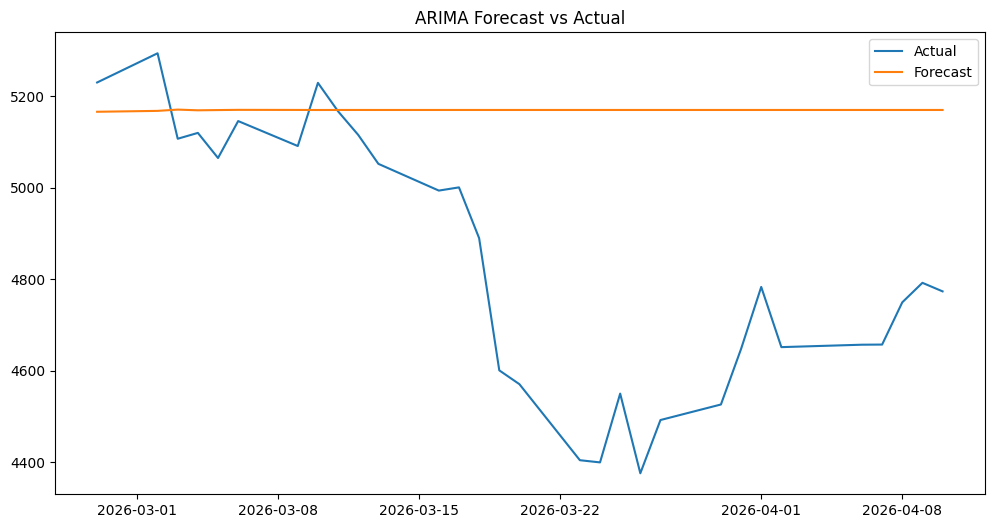

In [18]:
# ARIMA model
# Use the last part for testing
train_arima = daily_data['Close'][:-30]
test_arima = daily_data['Close'][-30:]

model_arima = ARIMA(train_arima, order=(5,1,0))  # Example order, can be tuned
model_arima_fit = model_arima.fit()

# Forecast
forecast = model_arima_fit.forecast(steps=30)
rmse_arima = np.sqrt(mean_squared_error(test_arima, forecast))
print(f'ARIMA RMSE: {rmse_arima}')

# Plot
plt.figure(figsize=(12,6))
plt.plot(test_arima.index, test_arima, label='Actual')
plt.plot(test_arima.index, forecast, label='Forecast')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

## Linear Regression Model

As another approach, we can use linear regression with lagged features for prediction.

Linear Regression RMSE: 113.16800585635958


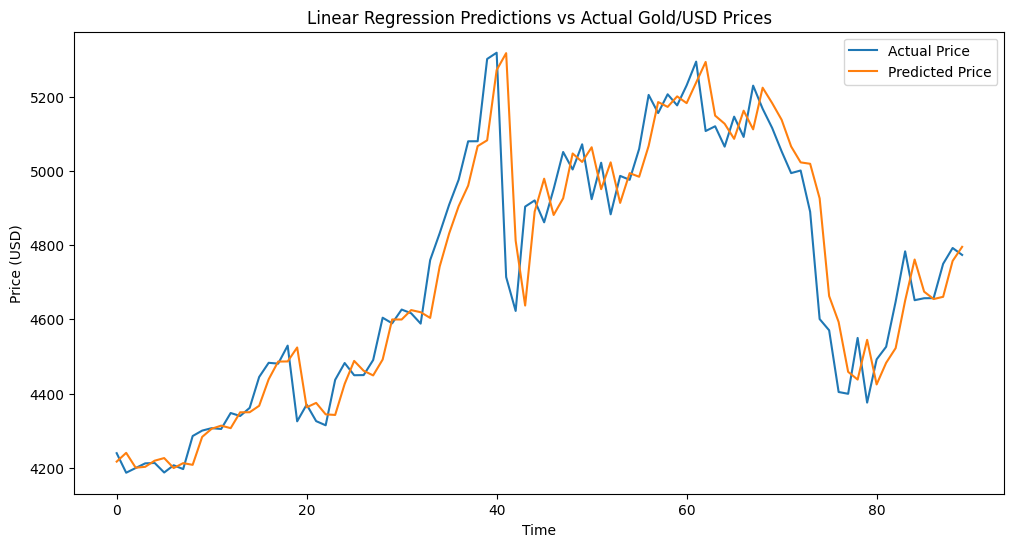

In [23]:
# Linear Regression model
lags = 5  # Use last 5 days as features
features = []
targets = []
for i in range(lags, len(scaled_data)):
    features.append(scaled_data[i-lags:i].flatten())
    targets.append(scaled_data[i])

features = np.array(features)
targets = np.array(targets)

# Split into train and test (last 30 days for test, same as ARIMA)
test_days = 90
train_features = features[:-test_days]
test_features = features[-test_days:]
train_targets = targets[:-test_days]
test_targets = targets[-test_days:]

# Train model
reg = LinearRegression()
reg.fit(train_features, train_targets)

# Predict
predictions_reg = reg.predict(test_features)

# Inverse transform for RMSE
predictions_reg_inv = scaler.inverse_transform(predictions_reg.reshape(-1, 1))
test_targets_inv = scaler.inverse_transform(test_targets.reshape(-1, 1))

rmse_reg = np.sqrt(mean_squared_error(test_targets_inv, predictions_reg_inv))
print(f'Linear Regression RMSE: {rmse_reg}')

# Plot
plt.figure(figsize=(12,6))
plt.plot(test_targets_inv, label='Actual Price')
plt.plot(predictions_reg_inv, label='Predicted Price')
plt.title('Linear Regression Predictions vs Actual Gold/USD Prices')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## Model Evaluation and Comparison

Compare the RMSE values of the three models: LSTM, ARIMA, and Linear Regression.

In [19]:
# Model Comparison
print("Model Performance Comparison:")
print(f"LSTM RMSE: {rmse}")
print(f"ARIMA RMSE: {rmse_arima}")
print(f"Linear Regression RMSE: {rmse_reg}")

# Determine the best model
rmses = {'LSTM': rmse, 'ARIMA': rmse_arima, 'Linear Regression': rmse_reg}
best_model = min(rmses, key=rmses.get)
print(f"\nBest performing model: {best_model} with RMSE {rmses[best_model]}")

Model Performance Comparison:
LSTM RMSE: 289.6385282188464
ARIMA RMSE: 434.3108217637347
Linear Regression RMSE: 110.69997460449268

Best performing model: Linear Regression with RMSE 110.69997460449268
